# EXPLORATORY DATA ANALYSIS

### Author: Gordon Moenga

# Businness Understanding
### Problem Statement

The dataset contained transaction-level records with multiple numerical variables related to customer purchases. The analysis needed to determine how transaction values were distributed, identify unusual observations, and understand the relationships between purchasing variables while distinguishing genuine purchasing patterns from potential data-quality issues.

### Project Objective

The objective was to conduct an exploratory analysis of the transaction data to:

* Understand the distribution and variability of key numerical variables.
* Identify trends, patterns, and potential outliers.
* Examine relationships between purchasing variables and transaction value.
* Assess the consistency between recorded and calculated transaction totals.
* Translate the findings into actionable business insights and recommendations.


# Methodology

The analysis followed a structured Exploratory Data Analysis (EDA) process using the following methods:

**Data Understanding:** Reviewed the dataset structure, dimensions, data types, and numerical variables to establish the scope of the analysis.

**Descriptive Statistics:** Calculated count, mean, median, standard deviation, minimum, maximum, and quartiles to understand the central tendency and variability of each numerical variable.

**Distribution Analysis:** Used histograms and boxplots to examine the distribution of numerical variables, identify skewness, and observe the spread of transaction values.

**Outlier Analysis:** Applied the Interquartile Range (IQR) method to identify observations that fell outside the expected range and assessed whether they represented genuine purchasing behavior or potential data-quality issues.

**Correlation Analysis:** Calculated Pearson correlation coefficients and visualized the correlation matrix to identify the strength and direction of relationships between numerical variables.

**Key Findings:** Synthesized the statistical results into key business insights, distinguishing meaningful purchasing patterns from potential data-quality artifacts.

**Recommendations:** Translated the findings into practical recommendations for interpreting transaction values, investigating high-value purchases, and maintaining transaction validation controls.

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Load the dataset

In [2]:
dataset = pd.read_csv("cleaned_dataset.csv")
dataset.head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedTotal,PriceDifference
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10,0.000000e+00
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70,0.000000e+00
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40,4.547474e-13
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,0.000000e+00
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04,0.000000e+00
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72,491.72,0.000000e+00
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42,664.42,0.000000e+00
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75,747.75,0.000000e+00
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,No Coupon,Email,268.56,268.56,0.000000e+00
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52,2037.52,0.000000e+00


In [3]:
# provide a summary for the dataset
dataset.describe(include='all')

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedTotal,PriceDifference
count,1200,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200,1200,1200.000000,1200,1200,1200.000000,1200.000000,1.200000e+03
unique,1200,671,1189,7,NaN,NaN,655,5,5,1200,NaN,4,5,NaN,NaN,NaN
top,ORD200000,2023-08-20,C38840,Printer,NaN,NaN,533 Main St,Online,Cancelled,TRK37947903,NaN,FREESHIP,Instagram,NaN,NaN,NaN
freq,1,8,2,181,NaN,NaN,8,258,250,1,NaN,313,259,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2.945833,356.412750,NaN,NaN,NaN,NaN,5.485000,NaN,NaN,1053.968300,1053.968300,2.676378e-15
std,NaN,NaN,NaN,NaN,1.407557,197.177146,NaN,NaN,NaN,NaN,2.281983,NaN,NaN,819.856558,819.856558,8.098100e-14
min,NaN,NaN,NaN,NaN,1.000000,11.390000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,11.390000,11.390000,-4.547474e-13
25%,NaN,NaN,NaN,NaN,2.000000,186.062500,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,410.520000,410.520000,0.000000e+00
50%,NaN,NaN,NaN,NaN,3.000000,364.210000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,823.615000,823.615000,0.000000e+00
75%,NaN,NaN,NaN,NaN,4.000000,521.570000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,1578.475000,1578.475000,0.000000e+00


## Descriptive Analysis

#### Identify Numerical columnns

In [4]:
numeric_columns = (
    dataset.select_dtypes(include=np.number)
    .columns
)
numeric_columns

Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'CalculatedTotal',
       'PriceDifference'],
      dtype='object')

In [19]:
# generate the core statistics
stats = pd.DataFrame({
    'count': dataset[numeric_columns].count(),
    'mean': dataset[numeric_columns].mean(),
    'median': dataset[numeric_columns].median(),
    'std Dev': dataset[numeric_columns].std(),
    'min': dataset[numeric_columns].min(),
    'max': dataset[numeric_columns].max(),
    '25%': dataset[numeric_columns].quantile(0.25),
    '50%': dataset[numeric_columns].quantile(0.50),
    '75%': dataset[numeric_columns].quantile(0.75)
})
stats

,count,mean,median,std Dev,min,max,25%,50%,75%
Quantity,1200,2.945833e+00,3.000,1.407557e+00,1.000000e+00,5.000000e+00,2.0000,3.000,4.000
UnitPrice,1200,3.564128e+02,364.210,1.971771e+02,1.139000e+01,6.999300e+02,186.0625,364.210,521.570
ItemsInCart,1200,5.485000e+00,5.000,2.281983e+00,1.000000e+00,1.000000e+01,4.0000,5.000,7.000
TotalPrice,1200,1.053968e+03,823.615,8.198566e+02,1.139000e+01,3.456400e+03,410.5200,823.615,1578.475
CalculatedTotal,1200,1.053968e+03,823.615,8.198566e+02,1.139000e+01,3.456400e+03,410.5200,823.615,1578.475
PriceDifference,1200,2.676378e-15,0.000,8.098100e-14,-4.547474e-13,4.547474e-13,0.0000,0.000,0.000


### Mean vs Median

In [20]:
stats['mean_median_diff'] = (
    stats['mean'] - stats['median']
)
stats.sort_values('mean_median_diff', ascending=False)
stats

,count,mean,median,std Dev,min,max,25%,50%,75%,mean_median_diff
Quantity,1200,2.945833e+00,3.000,1.407557e+00,1.000000e+00,5.000000e+00,2.0000,3.000,4.000,-5.416667e-02
UnitPrice,1200,3.564128e+02,364.210,1.971771e+02,1.139000e+01,6.999300e+02,186.0625,364.210,521.570,-7.797250e+00
ItemsInCart,1200,5.485000e+00,5.000,2.281983e+00,1.000000e+00,1.000000e+01,4.0000,5.000,7.000,4.850000e-01
TotalPrice,1200,1.053968e+03,823.615,8.198566e+02,1.139000e+01,3.456400e+03,410.5200,823.615,1578.475,2.303533e+02
CalculatedTotal,1200,1.053968e+03,823.615,8.198566e+02,1.139000e+01,3.456400e+03,410.5200,823.615,1578.475,2.303533e+02
PriceDifference,1200,2.676378e-15,0.000,8.098100e-14,-4.547474e-13,4.547474e-13,0.0000,0.000,0.000,2.676378e-15


## Distribution Analysis

### Histograms

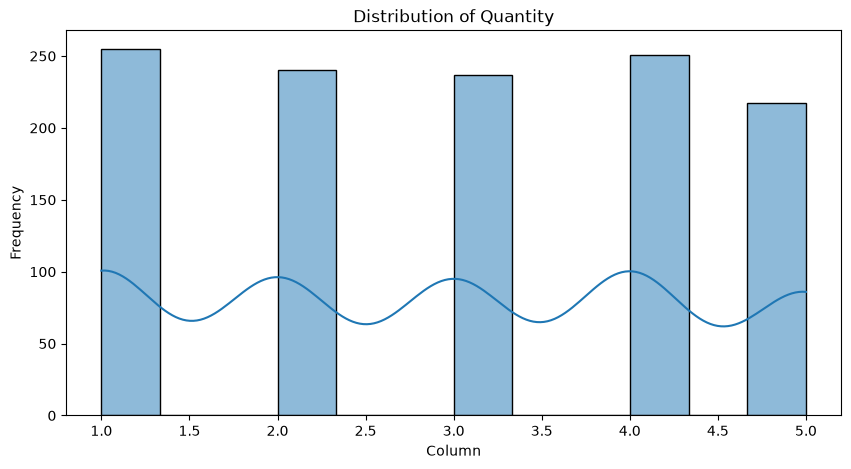

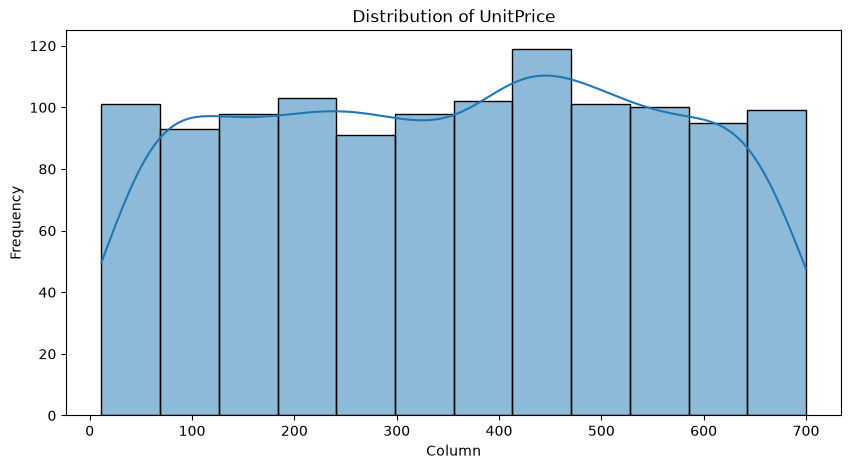

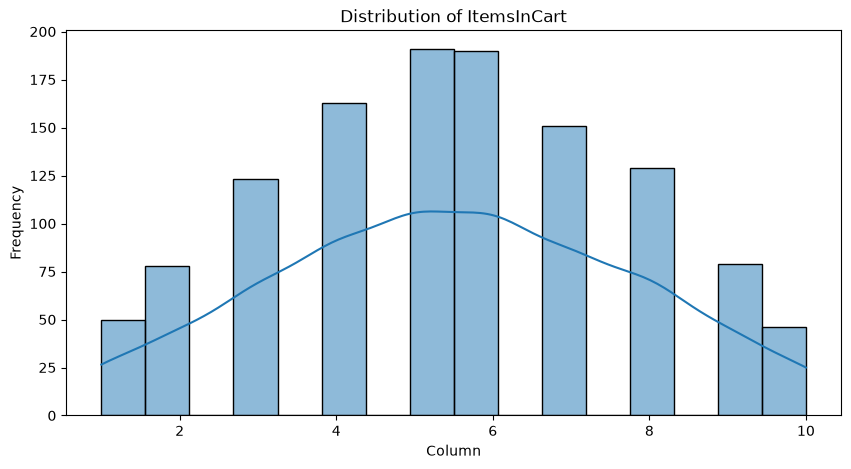

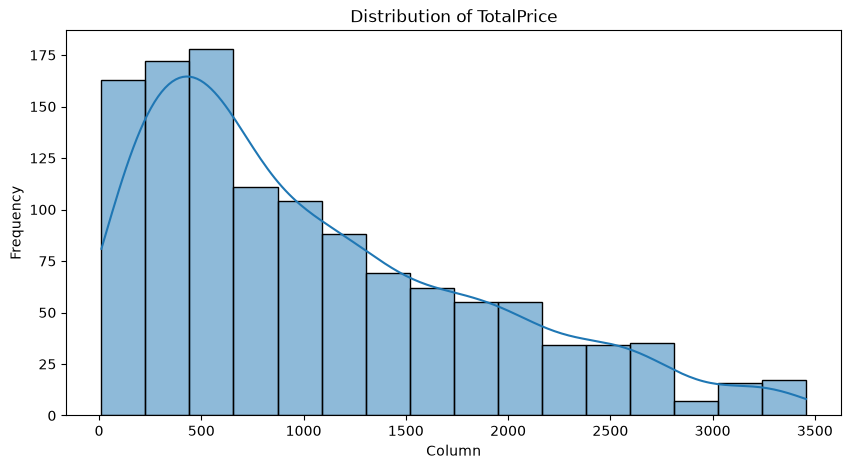

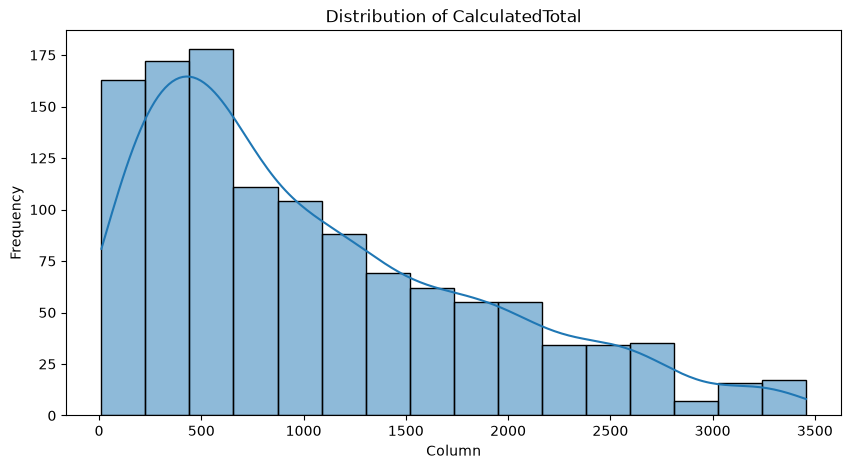

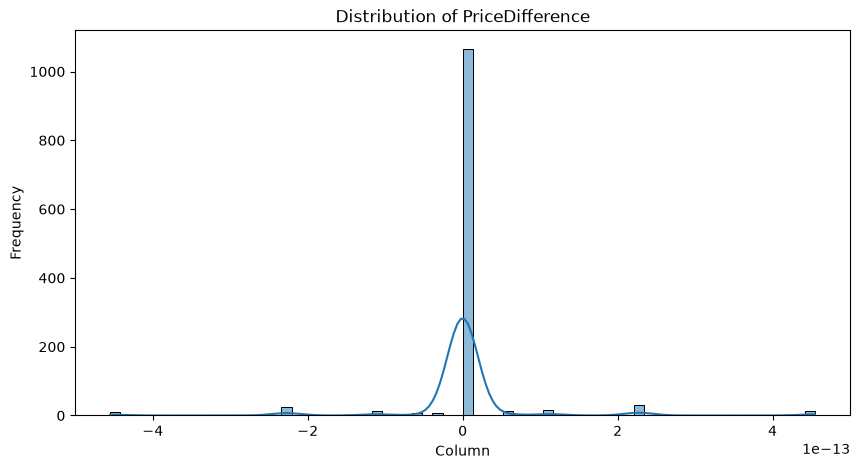

In [21]:
for column in numeric_columns:
    plt.figure(figsize=(10,5))
    sns.histplot(dataset[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel('Column')
    plt.ylabel('Frequency')
    plt.show()

## Outlier Analysis

### IQR Ranges

In [9]:
outlier_summary = []

for column in numeric_columns:
    Q1 = dataset[column].quantile(0.25)
    Q3 = dataset[column].quantile(0.50)

    IQR = Q3 - Q1

    lower_bound  = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataset[(dataset[column] < lower_bound) | (dataset[column] > upper_bound)]

    outlier_summary.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outliers %": (len(outliers) / len(dataset)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outliers %
0,Quantity,2.0000,3.000,1.0000,0.50000,4.50000,217,18.083333
1,UnitPrice,186.0625,364.210,178.1475,-81.15875,631.43125,115,9.583333
2,ItemsInCart,4.0000,5.000,1.0000,2.50000,6.50000,533,44.416667
3,TotalPrice,410.5200,823.615,413.0950,-209.12250,1443.25750,335,27.916667
4,CalculatedTotal,410.5200,823.615,413.0950,-209.12250,1443.25750,335,27.916667
5,PriceDifference,0.0000,0.000,0.0000,0.00000,0.00000,134,11.166667


### Ranking Variables

In [10]:
# Rank variables by outlier frequency
outlier_summary.sort_values('Outliers %', ascending=False)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outliers %
2,ItemsInCart,4.0000,5.000,1.0000,2.50000,6.50000,533,44.416667
3,TotalPrice,410.5200,823.615,413.0950,-209.12250,1443.25750,335,27.916667
4,CalculatedTotal,410.5200,823.615,413.0950,-209.12250,1443.25750,335,27.916667
0,Quantity,2.0000,3.000,1.0000,0.50000,4.50000,217,18.083333
5,PriceDifference,0.0000,0.000,0.0000,0.00000,0.00000,134,11.166667
1,UnitPrice,186.0625,364.210,178.1475,-81.15875,631.43125,115,9.583333


### Visualize the Variables

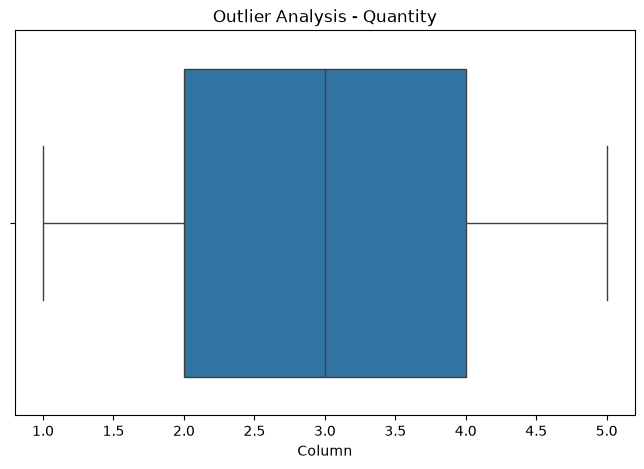

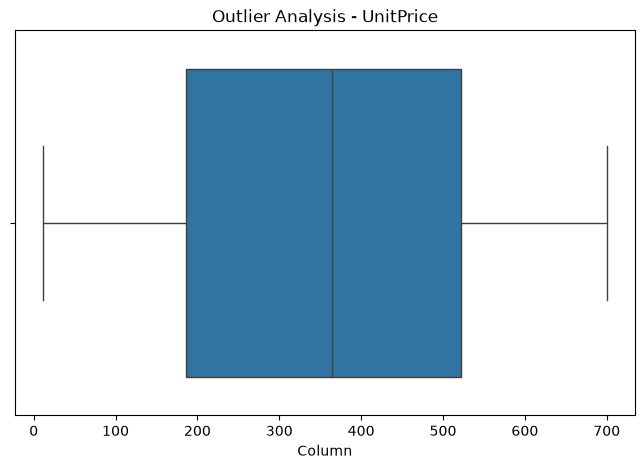

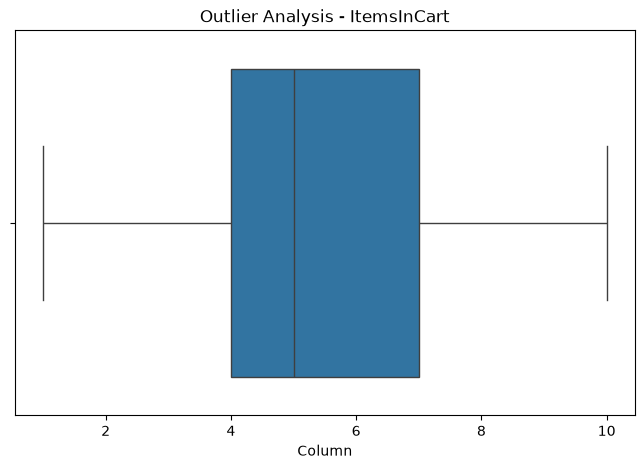

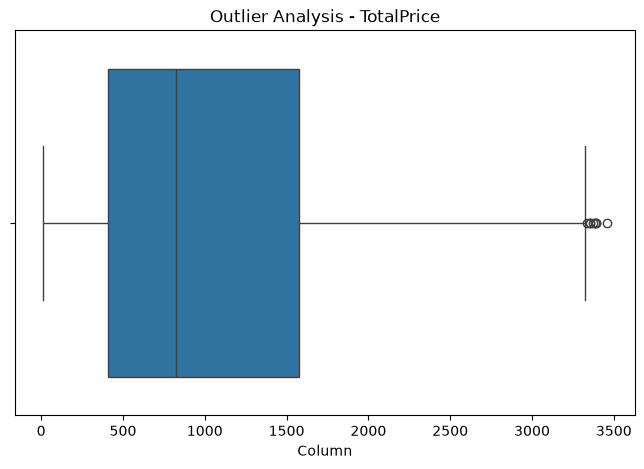

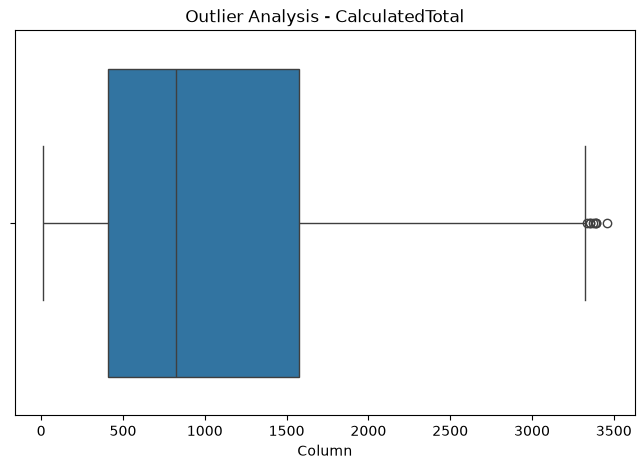

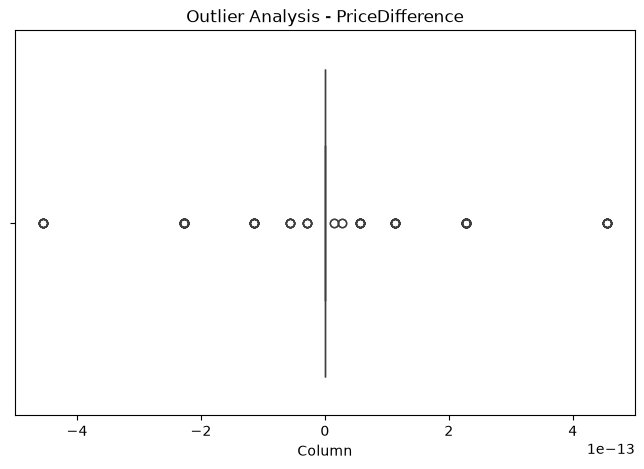

In [11]:
for column in numeric_columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x= dataset[column])
    plt.xlabel('Column')
    plt.title(f"Outlier Analysis - {column}")
    plt.show()

### Correlation Analysis

In [14]:
correlation_matrix = dataset[numeric_columns].corr()
correlation_matrix

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CalculatedTotal,PriceDifference
Quantity,1.000000,0.014553,0.650061,0.615251,0.615251,0.017702
UnitPrice,0.014553,1.000000,0.000602,0.717081,0.717081,0.033182
ItemsInCart,0.650061,0.000602,1.000000,0.392540,0.392540,-0.019088
TotalPrice,0.615251,0.717081,0.392540,1.000000,1.000000,0.043175
CalculatedTotal,0.615251,0.717081,0.392540,1.000000,1.000000,0.043175
PriceDifference,0.017702,0.033182,-0.019088,0.043175,0.043175,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

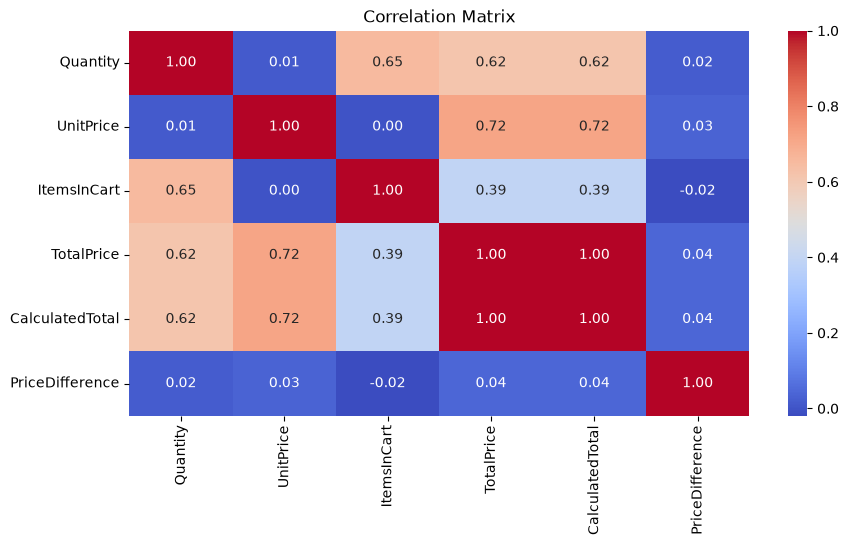

In [17]:
# visualising the correlation the matrix
plt.figure(figsize=(10,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show

# Key Findings

**1. Transaction values showed substantial variation**

TotalPrice recorded a mean of 1,053.97 compared with a median of 823.62, while the standard deviation was 819.86 and the maximum transaction value reached 3,456.40. This indicates that higher-value transactions had a considerable influence on the overall average.

**2. UnitPrice demonstrated the strongest numerical relationship with transaction value**

UnitPrice had a strong positive correlation with TotalPrice (r = 0.72), followed by Quantity (r = 0.62). This indicates that differences in unit pricing and purchase volume were closely associated with variations in transaction value.

**3. Purchase volume and cart size were strongly associated**

The average Quantity was 2.95 units, compared with a median of 3, while ItemsInCart had a mean of 5.49 and a median of 5. The two variables also showed a positive correlation (r = 0.65), indicating that larger carts were generally associated with higher purchase quantities.

**4. A substantial number of TotalPrice observations were identified as potential outliers**

The IQR analysis flagged 335 observations (27.9%), reflecting the considerable spread in transaction values. These observations warranted further investigation to determine whether they represented legitimate high-value purchases or distinct purchasing patterns.

**5. The IQR method flagged a high proportion of larger cart sizes as potential outliers**

533 ItemsInCart observations (44.4%) were classified as outliers. However, because ItemsInCart was a discrete variable ranging from 1 to 10, these observations were more appropriately interpreted as larger cart sizes rather than automatically being considered data-quality errors.

**6. Recorded and calculated transaction totals were internally consistent**

TotalPrice and CalculatedTotal had identical distributions, while PriceDifference remained effectively zero across the dataset. No meaningful discrepancies were identified between the recorded and independently calculated transaction totals.

# Recommendations

**1. Use median alongside mean when reporting transaction value**

TotalPrice has a mean of 1,053.97 versus a median of 823.62, reporting both measures will give a more accurate view of typical customer spending and prevent high-value transactions from distorting performance interpretation.

**2. Investigate the drivers of high-value transactions**

With 27.9% of TotalPrice observations flagged as potential outliers and a maximum transaction value of 3,456.40, segment high-value transactions to determine whether they are driven by higher unit prices, larger quantities, or larger carts.

**3. Focus purchasing analysis on UnitPrice and Quantity**

Since UnitPrice (r = 0.72) and Quantity (r = 0.62) have the strongest relationships with the total price, future analysis should examine how pricing and purchase volume differ across customer or product segments.

**4. Analyze larger carts as a distinct purchasing segment**

44.4% of ItemsInCart are flagged by the IQR rule, but because the variable ranges from 1–10 and is discrete, these should not automatically be removed. Instead, compare customers with larger versus typical carts to understand their purchasing behavior and value.

**5. Preserve legitimate high-volume observations during future analysis**

The relationship between ItemsInCart and quantity (r = 0.65) suggests that larger carts correspond with higher purchase volumes. Outlier treatment should therefore distinguish genuine high-volume behavior from actual data-quality errors.

**6. Maintain automated transaction validation**

Since PriceDifference is effectively zero and TotalPrice matches CalculatedTotal, retain the calculation check as a data-quality control to ensure future transaction records remain internally consistent.